In [1]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import (summarize, poly, ModelSpec as MS)
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_squared_error
from ISLP import load_data , confusion_table
from ISLP.models import ModelSpec as MS
import matplotlib.pyplot as plt

In [5]:
from pygam import (s as s_gam, l as l_gam, f as f_gam, LinearGAM, LogisticGAM)
from ISLP.transforms import (BSpline, NaturalSpline)
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,degrees_of_freedom, plot as plot_gam, anova as anova_gam)
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Lasso

In [3]:
from ISLP import load_data
boston=load_data("Boston")
X = boston.drop(columns='medv')
y = boston['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=8)
print(boston)

        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     ptratio  lstat  medv  
0       15.3   4.98  24.0  
1       17.8   9.14  21.6  
2       17.8   4.03  34.7  
3       18.

In [6]:
### Linear Regression ###
lm = LinearRegression()
lm.fit(X_train, y_train)
lm_pred = lm.predict(X_test)
mse_lm = mean_squared_error(y_test, lm_pred)
print(f"Linear Regression MSE: {mse_lm:.4f}")

Linear Regression MSE: 26.7580


In [7]:
poly_rm = MS([poly('rm', degree=4)]).fit(boston)
M = sm.OLS(y, poly_rm.transform(boston)).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,22.5328,0.268,84.001,0.0
"poly(rm, degree=4)[0]",143.7164,6.034,23.818,0.0
"poly(rm, degree=4)[1]",52.6526,6.034,8.726,0.0
"poly(rm, degree=4)[2]",-23.3832,6.034,-3.875,0.0
"poly(rm, degree=4)[3]",-22.4043,6.034,-3.713,0.0


In [8]:
#  see the fitting
rm=boston['rm']
rm_grid = np.linspace(rm.min(), rm.max(), 100)
rm_df = pd.DataFrame({'rm': rm_grid})

In [9]:
#define a general plot function
def plot_rm_fit(rm_df, basis_list, titles):
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(10, 8))

    # Scatter plot of the original data
    ax.scatter(rm, y, facecolor='gray', alpha=0.5, label='Data')

    # Loop through each basis and title to plot each fit
    for basis, title, color in zip(basis_list, titles, ['b', 'g']):
        X = basis.transform(boston)
        Xnew = basis.transform(rm_df)
        M = sm.OLS(y, X).fit()
        preds = M.get_prediction(Xnew)
        bands = preds.conf_int(alpha=0.05)

        # Plot the predicted mean and confidence bands
        ax.plot(rm_df.values, preds.predicted_mean, color=color, label=title, linewidth=3)
        ax.plot(rm_df.values, bands[:, 0], f'{color}--', linewidth=1, alpha=0.6)
        ax.plot(rm_df.values, bands[:, 1], f'{color}--', linewidth=1, alpha=0.6)

    # Set title and labels
    ax.set_title('Comparison of Fits', fontsize=20)
    ax.set_xlabel('rm', fontsize=20)
    ax.set_ylabel('medv', fontsize=20)
    ax.legend(fontsize=15)

    return ax


<Axes: title={'center': 'Comparison of Fits'}, xlabel='rm', ylabel='medv'>

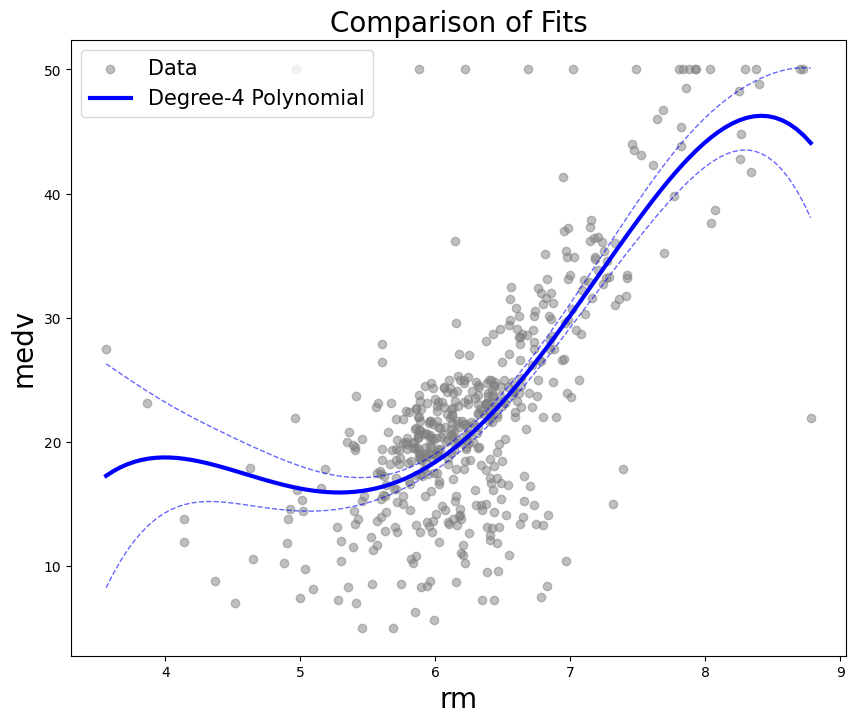

In [10]:
basis_list = [poly_rm]
titles=['Degree-4 Polynomial']
plot_rm_fit(rm_df, basis_list, titles)

In [11]:
##anova approach to determine the order
models = [MS([poly('rm', degree=d)])
for d in range(1, 6)]
Xs = [model.fit_transform(boston) for model in models]
anova_lm(*[sm.OLS(y, X_).fit() for X_ in Xs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,504.0,22061.879196,0.0,NaN,NaN,NaN
1,503.0,19289.583875,1.0,2772.295321,79.217393,1.009717e-17
2,502.0,18742.811652,1.0,546.772222,15.623830,8.836403e-05
3,501.0,18240.859922,1.0,501.951730,14.343099,1.708236e-04
4,500.0,17498.021729,1.0,742.838193,21.226348,5.185708e-06


In [12]:
####different rm groups####
cut_rm = pd.qcut(rm , 4)
summarize(sm.OLS(y, pd.get_dummies(cut_rm)).fit())

,coef,std err,t,P>|t|
"(3.56, 5.885]",17.1528,0.630,27.234,0.0
"(5.885, 6.208]",19.2325,0.632,30.415,0.0
"(6.208, 6.624]",21.3738,0.632,33.801,0.0
"(6.624, 8.78]",32.3370,0.630,51.342,0.0


In [13]:
#####cubic spline ######
bs_rm = MS([bs('rm', internal_knots=[4,6,7])])
Xbs = bs_rm.fit_transform(boston)
M = sm.OLS(y, Xbs).fit()
summarize(M)


,coef,std err,t,P>|t|
intercept,27.6886,5.926,4.673,0.000
"bs(rm, internal_knots=[4, 6, 7])[0]",-9.9518,8.362,-1.190,0.235
"bs(rm, internal_knots=[4, 6, 7])[1]",-16.3043,6.837,-2.385,0.017
"bs(rm, internal_knots=[4, 6, 7])[2]",-11.0840,6.145,-1.804,0.072
"bs(rm, internal_knots=[4, 6, 7])[3]",-0.6046,6.163,-0.098,0.922
"bs(rm, internal_knots=[4, 6, 7])[4]",33.7297,6.692,5.040,0.000
"bs(rm, internal_knots=[4, 6, 7])[5]",9.3677,6.842,1.369,0.172


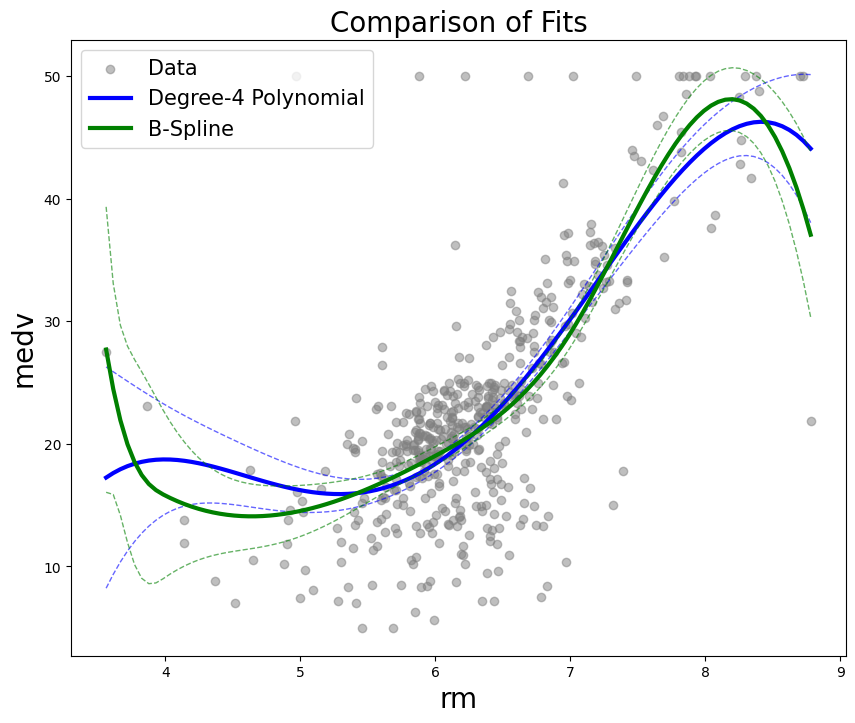

In [14]:
basis_list = [poly_rm, bs_rm]
titles = ['Degree-4 Polynomial', 'B-Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.show()

In [15]:
###specify degree of freedom###
bs_rm0 = MS([bs('rm', df=3, degree=2)]).fit(boston)
Xbs0 = bs_rm0.transform(boston)
summarize(sm.OLS(y, Xbs0).fit())

,coef,std err,t,P>|t|
intercept,22.9887,3.466,6.632,0.000
"bs(rm, df=3, degree=2)[0]",-15.6781,4.154,-3.774,0.000
"bs(rm, df=3, degree=2)[1]",10.6432,3.267,3.258,0.001
"bs(rm, df=3, degree=2)[2]",31.1041,4.389,7.087,0.000


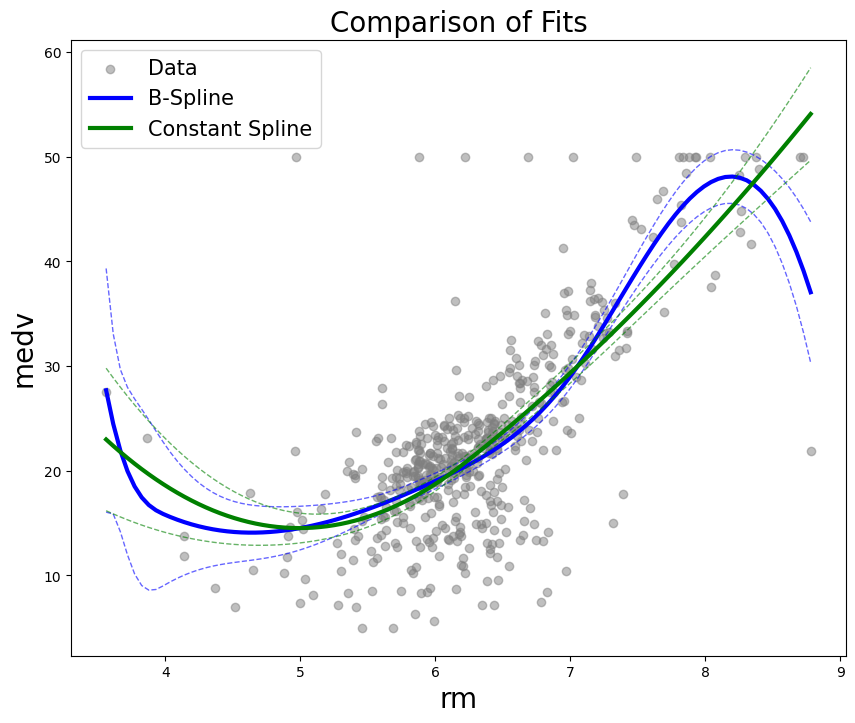

In [16]:
basis_list = [bs_rm, bs_rm0]
titles = ['B-Spline', 'Constant Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.show()

In [17]:
####NaturalSpline###
ns_rm = MS([ns('rm', df=5)]).fit(boston)
M_ns = sm.OLS(y, ns_rm.transform(boston)).fit()
summarize(M_ns)

,coef,std err,t,P>|t|
intercept,21.0068,3.532,5.947,0.000
"ns(rm, df=5)[0]",0.2822,3.396,0.083,0.934
"ns(rm, df=5)[1]",-2.6922,3.715,-0.725,0.469
"ns(rm, df=5)[2]",23.3297,2.414,9.665,0.000
"ns(rm, df=5)[3]",13.5953,7.778,1.748,0.081
"ns(rm, df=5)[4]",32.4341,2.783,11.654,0.000


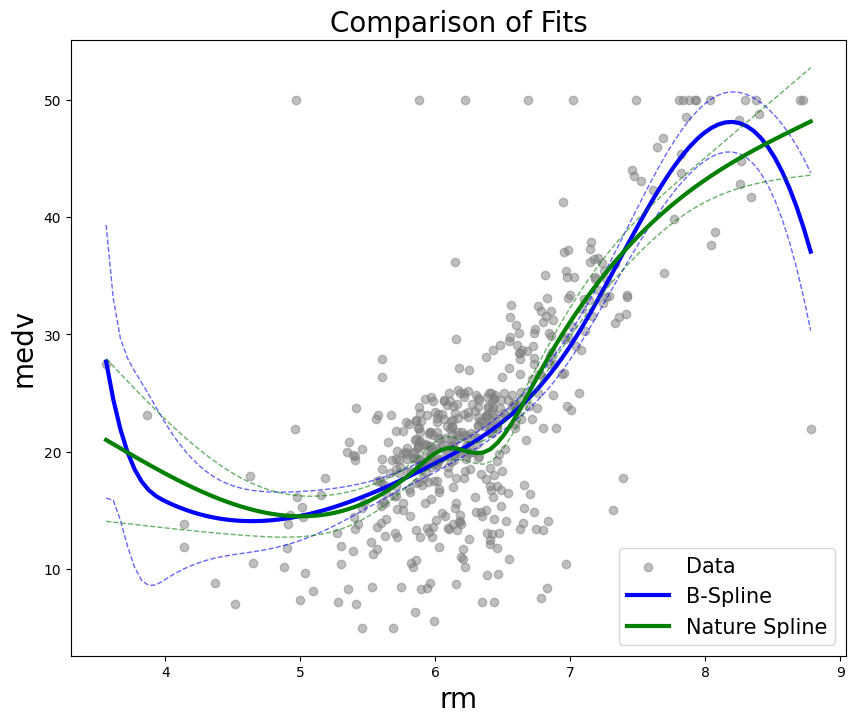

In [18]:
basis_list = [bs_rm, ns_rm]
titles = ['B-Spline', 'Nature Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.show()

In [20]:
X_rm = np.asarray(rm).reshape((-1,1))
gam = LinearGAM(s_gam(0, lam=3.98)).fit(X_rm, y)
gam_opt = gam.gridsearch(X_rm , y)
best_lambda = gam_opt.lam
print(f"Best lambda: {best_lambda}")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Best lambda: [[3.981071705534969]]


In [21]:
# Define a modified plot function to include the smoothing spline fit
def plot_rm_fit_extended(rm_df, basis_list, titles, colors):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Scatter plot of the original data
    ax.scatter(rm, y, facecolor='gray', alpha=0.5, label='Original Data')

    # Loop through each basis, title, and color to plot each fit
    for basis, title, color in zip(basis_list, titles, colors):
        if isinstance(basis, LinearGAM):
            # For smoothing spline fit
            y_pred = basis.predict(rm_df.values.reshape(-1, 1))
            ax.plot(rm_df.values, y_pred, color=color, label=title, linewidth=3)
        else:
            # For B-spline and natural spline fits
            X_new = basis.transform(boston)
            M = sm.OLS(y, X_new).fit()
            preds = M.get_prediction(basis.transform(rm_df))
            bands = preds.conf_int(alpha=0.05)

            ax.plot(rm_df.values, preds.predicted_mean, color=color, label=title, linewidth=3)
            ax.plot(rm_df.values, bands[:, 0], f'{color}--', linewidth=1, alpha=0.6)
            ax.plot(rm_df.values, bands[:, 1], f'{color}--', linewidth=1, alpha=0.6)

    # Set title and labels
    ax.set_title('Comparison of Spline Fits', fontsize=20)
    ax.set_xlabel('rm', fontsize=20)
    ax.set_ylabel('medv', fontsize=20)
    ax.legend(fontsize=15)

    return ax

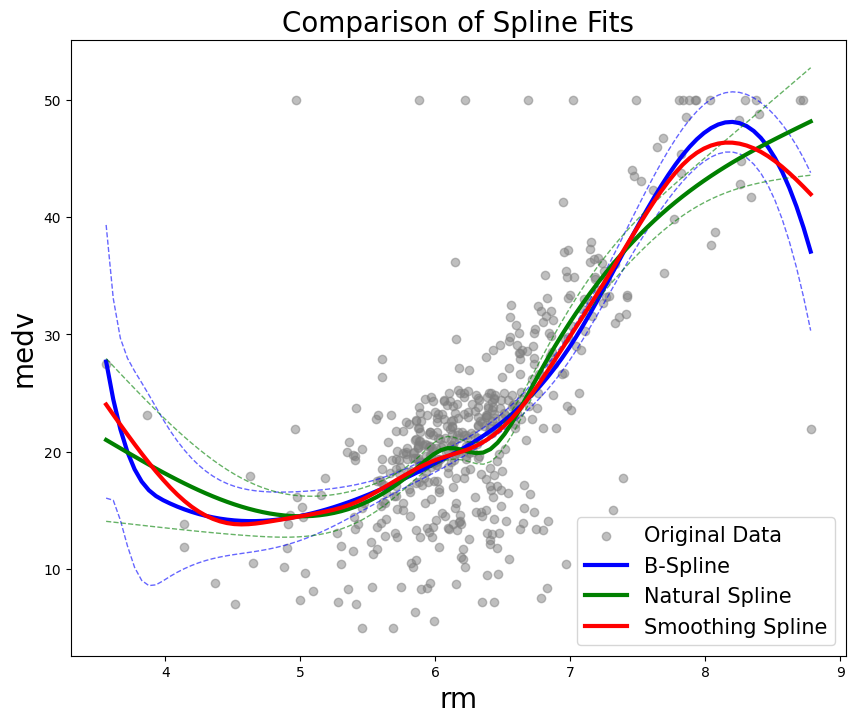

In [22]:
# Plot all spline fits on the same plot
basis_list = [bs_rm, ns_rm, gam]
titles = ['B-Spline', 'Natural Spline', 'Smoothing Spline']
colors = ['b', 'g', 'r']

rm_df = pd.DataFrame({'rm': np.linspace(rm.min(), rm.max(), 100)})
plot_rm_fit_extended(rm_df, basis_list, titles, colors)
plt.show()

In [23]:
#####GAM model###
# Prepare variables and basis functions for the GAM model
gam = LinearGAM(
    s_gam(0, lam=0.6) +  # Smoothing spline for the first feature ('crim')
    s_gam(1, lam=0.6) +  # Smoothing spline for the second feature ('zn')
    l_gam(2) +           # Linear term for the third feature ('indus')
    f_gam(3) +           # Linear term for the fourth feature (factor 'chas')
    s_gam(4) +           # Smoothing spline for 'nox'
    l_gam(5) +           # Linear term for 'rm'
    s_gam(6) +           # Smoothing spline for 'age'
    l_gam(7) +           # Linear term for 'dis'
    s_gam(8, lam=0.6) +  # Smoothing spline for 'rad'
    l_gam(9) +           # Linear term for 'tax'
    s_gam(10) +          # Smoothing spline for 'ptratio'
    s_gam(11, lam=0.6)   # Smoothing spline for 'lstat'
)

# Fit the model on the training data
gam.fit(X_train, y_train)

# Summarize the model fit
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     58.9454
Link Function:                     IdentityLink Log Likelihood:                                  -893.9854
Number of Samples:                          253 AIC:                                             1907.8615
                                                AICc:                                            1945.9069
                                                GCV:                                                22.422
                                                Scale:                                             13.2727
                                                Pseudo R-Squared:                                   0.8697
Feature Function                  Lam

C:\Users\erick\AppData\Local\Temp\ipykernel_50284\3906354990.py:22: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


In [24]:
# Predict on the test set
y_pred = gam.predict(X_test)

# Calculate mean squared error on test set
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

Test MSE: 20.3001


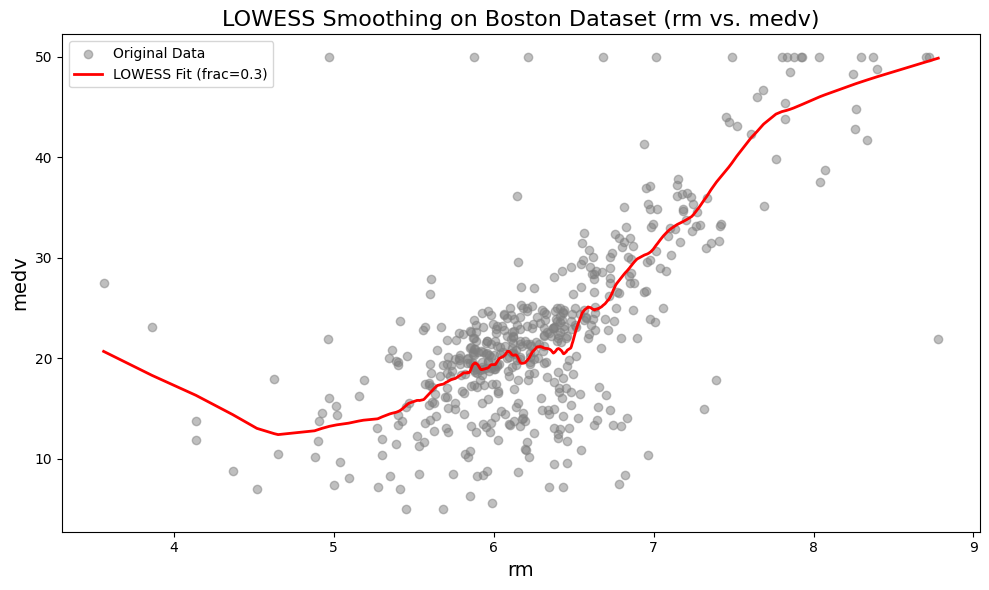

In [25]:
# Apply LOWESS smoothing
lowess_fit = sm.nonparametric.lowess(y, rm, frac=0.1)

# Extract the smoothed x and y values
rm_smoothed = lowess_fit[:, 0]
medv_smoothed = lowess_fit[:, 1]

# Plot the original data and the LOWESS fit
plt.figure(figsize=(10, 6))
plt.scatter(rm, y, facecolor='gray', alpha=0.5, label='Original Data')
plt.plot(rm_smoothed, medv_smoothed, color='r', label='LOWESS Fit (frac=0.3)', linewidth=2)
plt.xlabel('rm', fontsize=14)
plt.ylabel('medv', fontsize=14)
plt.title('LOWESS Smoothing on Boston Dataset (rm vs. medv)', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()